# Monte Carlo Portfolio Stress Test

This project applies a Monte Carlo simulation to evaluate downside risk
in a multi-asset portfolio. Historical market prices are used to
construct portfolio returns, estimate historical VaR and CVaR, and
generate simulated stress scenarios for potential extreme losses.

### Portfolio

- **SPY — Equities:** 50%
- **IEF — Bonds:** 30%
- **GLD — Gold:** 20%

### Methods

- Historical adjusted price data
- Log return calculation
- Portfolio aggregation
- Historical VaR and CVaR
- Monte Carlo simulation
- 99% stress-loss estimation
- Risk visualization

### Tools

Python, `yfinance`, `pandas`, `numpy`, and `matplotlib`

## 1. Import libraries

The notebook uses `yfinance` for market data, `pandas` and `numpy` for
calculations, and `matplotlib` for visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

## 2. Define portfolio and analysis settings

The weights sum to 100%. The dates can be changed if a different
historical sample is preferred.

In [2]:
tickers = ["SPY", "IEF", "GLD"]

weights = pd.Series(
    [0.50, 0.30, 0.20],
    index=tickers,
    name="Weight"
)

start_date = "2015-01-01"
end_date = "2025-12-31"

confidence_level = 0.99
simulations = 10_000
random_seed = 42

print("Portfolio weights:")
print(weights)
print("\nSum of weights:", weights.sum())

Portfolio weights:
SPY   0.500000
IEF   0.300000
GLD   0.200000
Name: Weight, dtype: float64

Sum of weights: 1.0

## 3. Download historical prices

`yfinance` is used to download daily adjusted market prices. With
`auto_adjust=True`, the downloaded OHLC data are adjusted for corporate
actions.

In [3]:
data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

prices = data["Close"].dropna()

print("Price data shape:", prices.shape)
display(prices.head())

Price data shape: (2765, 3)

## 4. Visualize normalized asset prices

Normalizing each series to 100 makes the relative historical performance
of the three assets easier to compare.

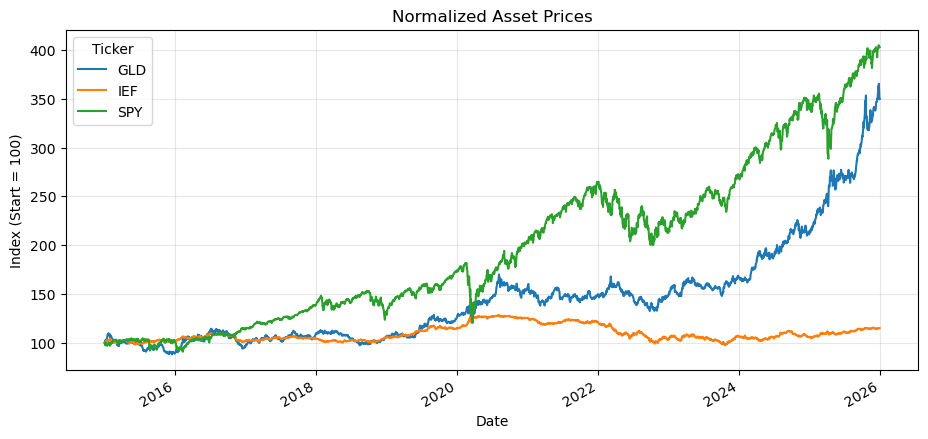

In [4]:
normalized_prices = prices / prices.iloc[0] * 100

ax = normalized_prices.plot(figsize=(11, 5))
ax.set_title("Normalized Asset Prices")
ax.set_xlabel("Date")
ax.set_ylabel("Index (Start = 100)")
ax.grid(alpha=0.3)
plt.show()

## 5. Calculate daily log returns

For each asset:

\[ r_t = () \]

Log returns are then aggregated using the portfolio weights.

In [5]:
log_returns = np.log(prices / prices.shift(1)).dropna()

portfolio_returns = log_returns.dot(weights)
portfolio_returns.name = "Portfolio Return"

display(log_returns.head())
display(portfolio_returns.head())

Date
2015-01-05   -0.004294
2015-01-06   -0.000457
2015-01-07    0.004955
2015-01-08    0.006725
2015-01-09   -0.000282
Name: Portfolio Return, dtype: float64

## 6. Portfolio return summary

The following statistics summarize the historical daily return
distribution. Annualized return and volatility use 252 trading days per
year.

In [6]:
mean_daily = portfolio_returns.mean()
std_daily = portfolio_returns.std()

annualized_return = mean_daily * 252
annualized_volatility = std_daily * np.sqrt(252)

summary = pd.Series({
    "Mean Daily Return": mean_daily,
    "Daily Volatility": std_daily,
    "Annualized Return": annualized_return,
    "Annualized Volatility": annualized_volatility,
    "Minimum Daily Return": portfolio_returns.min(),
    "Maximum Daily Return": portfolio_returns.max()
})

display(summary.to_frame("Value"))

print(f"Annualized return: {annualized_return:.2%}")
print(f"Annualized volatility: {annualized_volatility:.2%}")

Annualized return: 9.01%
Annualized volatility: 9.64%

## 7. Historical VaR and CVaR at 99%

- **VaR (99%)** estimates the loss threshold exceeded in approximately
  the worst 1% of historical observations.
- **CVaR / Expected Shortfall (99%)** is the average loss conditional on
  being beyond that VaR threshold.

The notebook reports losses as positive percentages for easier
interpretation.

In [7]:
tail_probability = 1 - confidence_level

historical_threshold = np.quantile(portfolio_returns, tail_probability)
historical_var_99 = -historical_threshold

historical_tail = portfolio_returns[portfolio_returns <= historical_threshold]
historical_cvar_99 = -historical_tail.mean()

print(f"Historical VaR (99%):  {historical_var_99:.2%}")
print(f"Historical CVaR (99%): {historical_cvar_99:.2%}")
print(f"Historical tail observations: {len(historical_tail)}")

Historical VaR (99%):  1.65%
Historical CVaR (99%): 2.52%
Historical tail observations: 28

## 8. Monte Carlo simulation

A simple parametric Monte Carlo model is used. It assumes daily
portfolio returns follow a normal distribution with the historical mean
and standard deviation.

This is intentionally a simple baseline stress model. Real financial
returns can exhibit skewness, fat tails, volatility clustering, and
regime changes.

In [8]:
np.random.seed(random_seed)

mean_return = portfolio_returns.mean()
std_return = portfolio_returns.std()

simulated_returns = np.random.normal(
    loc=mean_return,
    scale=std_return,
    size=simulations
)

print("Number of simulations:", len(simulated_returns))
print(f"Simulated mean return: {simulated_returns.mean():.4%}")
print(f"Simulated volatility:  {simulated_returns.std(ddof=1):.4%}")

Number of simulations: 10000
Simulated mean return: 0.0345%
Simulated volatility:  0.6092%

## 9. Monte Carlo 99% stress loss and Expected Shortfall

The 1st percentile of simulated returns is the 99% downside threshold.
Expected Shortfall averages simulated returns that fall below that
threshold.

In [9]:
mc_threshold = np.quantile(simulated_returns, tail_probability)
mc_var_99 = -mc_threshold

mc_tail = simulated_returns[simulated_returns <= mc_threshold]
mc_cvar_99 = -mc_tail.mean()

print(f"Monte Carlo VaR / Stress Loss (99%): {mc_var_99:.2%}")
print(f"Monte Carlo CVaR (99%):             {mc_cvar_99:.2%}")
print(f"Simulated tail observations:        {len(mc_tail)}")

Monte Carlo VaR / Stress Loss (99%): 1.37%
Monte Carlo CVaR (99%):             1.60%
Simulated tail observations:        100

## 10. Compare historical and Monte Carlo risk estimates

In [10]:
risk_comparison = pd.DataFrame({
    "Historical": [historical_var_99, historical_cvar_99],
    "Monte Carlo": [mc_var_99, mc_cvar_99]
}, index=["VaR 99%", "CVaR 99%"])

display(risk_comparison.style.format("{:.2%}"))

## 11. Visualize the simulated return distribution

The vertical lines show the Monte Carlo 99% VaR threshold and the Monte
Carlo CVaR level.

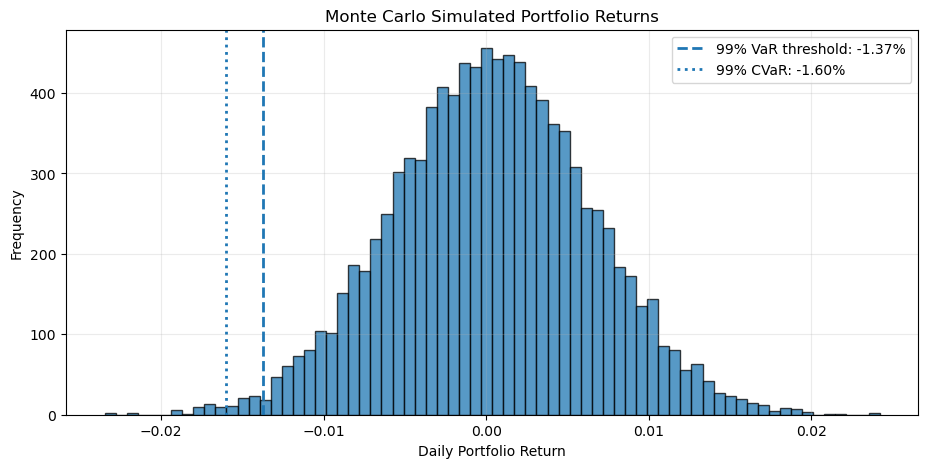

In [11]:
plt.figure(figsize=(11, 5))

plt.hist(simulated_returns, bins=70, alpha=0.75, edgecolor="black")
plt.axvline(mc_threshold, linestyle="--", linewidth=2, label=f"99% VaR threshold: {mc_threshold:.2%}")
plt.axvline(-mc_cvar_99, linestyle=":", linewidth=2, label=f"99% CVaR: {-mc_cvar_99:.2%}")

plt.title("Monte Carlo Simulated Portfolio Returns")
plt.xlabel("Daily Portfolio Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 12. Visualize historical portfolio returns

This chart helps identify periods in which the portfolio experienced
unusually large daily losses or gains.

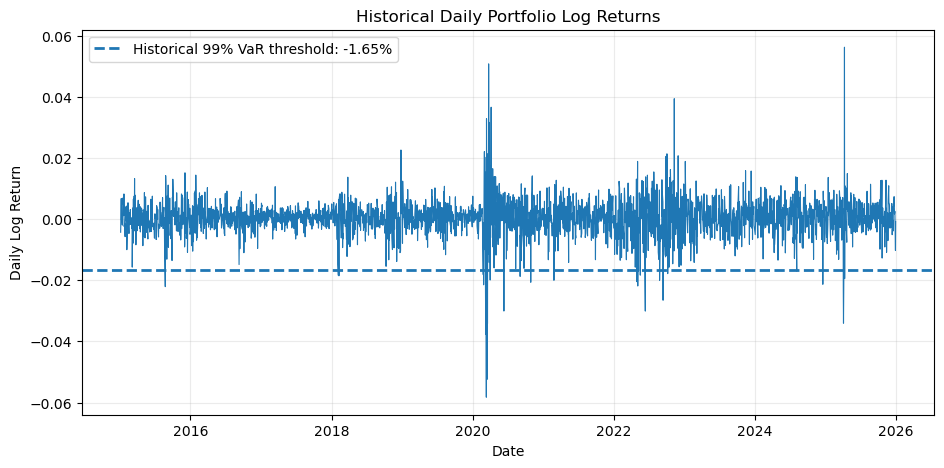

In [12]:
plt.figure(figsize=(11, 5))

plt.plot(portfolio_returns.index, portfolio_returns, linewidth=0.8)
plt.axhline(historical_threshold, linestyle="--", linewidth=2, label=f"Historical 99% VaR threshold: {historical_threshold:.2%}")

plt.title("Historical Daily Portfolio Log Returns")
plt.xlabel("Date")
plt.ylabel("Daily Log Return")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 13. Final stress-test summary

The final table brings together the portfolio composition, historical
downside-risk estimates, and Monte Carlo stress estimates.

In [13]:
final_results = pd.Series({
    "SPY Weight": weights["SPY"],
    "IEF Weight": weights["IEF"],
    "GLD Weight": weights["GLD"],
    "Historical VaR 99%": historical_var_99,
    "Historical CVaR 99%": historical_cvar_99,
    "Monte Carlo VaR 99%": mc_var_99,
    "Monte Carlo CVaR 99%": mc_cvar_99
})

display(final_results.to_frame("Result").style.format("{:.2%}"))

## Conclusion

This notebook evaluates downside risk for a diversified portfolio
consisting of equities, bonds, and gold. Historical VaR and CVaR
summarize extreme losses observed in the sample, while the Monte Carlo
simulation generates additional return scenarios based on the
portfolio’s historical mean and volatility.

The model provides a transparent baseline for portfolio stress testing.
A more advanced version could incorporate non-normal return
distributions, time-varying volatility, correlations that change during
crises, multi-day horizons, and explicit historical crisis scenarios.